# Лабораторная работа №2. Кластеризация клиентов интернет-магазина

#### Цель

- освоить методы k-means и агломеративной кластеризации на большом реальном датасете
транзакций
- научиться применять RFM-анализ для сегментации клиентов
- определять оптимальное число кластеров с помощью метода локтя и силуэтного анализа
- интерпретировать кластеры как бизнес-сегменты

#### Датасет

Online Retail по покупкам в интернет-магазине, локализованном в регионе с
индексом 1, пользователями из 39 регионов - 541 909 транзакций, 4 372 клиента, по ссылке
https://docs.google.com/spreadsheets/d/1liM0yHn0kFEBJppNjbjpf87wFKeSLvnx/edit?usp=sharing&ouid=114596079979601215791&rtpof=true&sd=true

#### Задача

Сегментировать клиентов по их покупательскому поведению, чтобы отдел маркетинга мог запускать таргетированные кампании: удерживать «ценных», реактивировать «спящих», стимулировать «новичков».

#### Признаки

| Признак | Описание |
|---|---|
| **InvoiceNo** | Номер счёта (6 цифр, уникальный для каждой транзакции) |
| **StockCode** | Код товара (5 цифр) |
| **Description** | Название товара |
| **Quantity** | Количество единиц товара в транзакции |
| **InvoiceDate** | Дата и время выставления счёта |
| **UnitPrice** | Цена за единицу товара |
| **CustomerID** | Идентификатор клиента (5 цифр) |
| **Region** | Код региона проживания клиента |

## Задание 1. Загрузка и EDA

In [1]:
import pandas as pd

In [2]:
df = pd.read_excel('https://docs.google.com/spreadsheets/d/1liM0yHn0kFEBJppNjbjpf87wFKeSLvnx/export?format=xlsx&id=1liM0yHn0kFEBJppNjbjpf87wFKeSLvnx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Region
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2024-12-01 08:26:00,285.60,17850.0,1
1,536365,71053,WHITE METAL LANTERN,6,2024-12-01 08:26:00,379.68,17850.0,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2024-12-01 08:26:00,308.00,17850.0,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2024-12-01 08:26:00,379.68,17850.0,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2024-12-01 08:26:00,379.68,17850.0,1


In [3]:
print(f'Строк: {len(df)}')
print(f'Пропуски:\n{df.isna().sum()}')
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)
df_returns = df[df['Quantity'] <= 0].copy()
df = df[(df['Quantity'] > 0) & df['UnitPrice'] > 0].copy()
print('\n')
print('ПОСЛЕ ОЧИСТКИ')
print(f'Покупок: {len(df)}')
print(f'Возвратов: {len(df_returns)}')
print(f'Уникальных клиентов: {df['CustomerID'].nunique()}')

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

Строк: 541909
Пропуски:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Region              0
dtype: int64


ПОСЛЕ ОЧИСТКИ
Покупок: 397884
Возвратов: 8905
Уникальных клиентов: 4338


In [4]:
df[['Quantity', 'UnitPrice', 'TotalPrice']].describe()

,Quantity,UnitPrice,TotalPrice
count,397884.000000,397884.000000,3.978840e+05
mean,12.988238,349.046629,2.508464e+03
std,179.331775,2474.962183,3.461596e+04
min,1.000000,0.112000,1.120000e-01
25%,2.000000,140.000000,5.241600e+02
50%,6.000000,218.400000,1.321600e+03
75%,12.000000,420.000000,2.217600e+03
max,80995.000000,911988.000000,1.886860e+07


Видно большой std относительно mean - большой разброс.
max сильно больше 75% - выбросы.

In [5]:
df['Region'].value_counts().head(10)

Region
1     354321
9       9040
2       8341
5       7236
7       2484
4       2359
13      2031
22      1841
28      1462
3       1182
Name: count, dtype: int64

По числу транзакций доминирует регион 1.

In [6]:
import matplotlib.pyplot as plt

%matplotlib inline

In [7]:
monthly = df.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum()
print(monthly)

InvoiceDate
2024-12-31    6.414396e+07
2025-01-31    6.377784e+07
2025-02-28    5.007938e+07
2025-03-31    6.669609e+07
2025-04-30    5.255044e+07
2025-05-31    7.600259e+07
2025-06-30    7.405593e+07
2025-07-31    6.721019e+07
2025-08-31    7.227852e+07
2025-09-30    1.067179e+08
2025-10-31    1.164037e+08
2025-11-30    1.301235e+08
2025-12-31    5.803759e+07
Freq: ME, Name: TotalPrice, dtype: float64


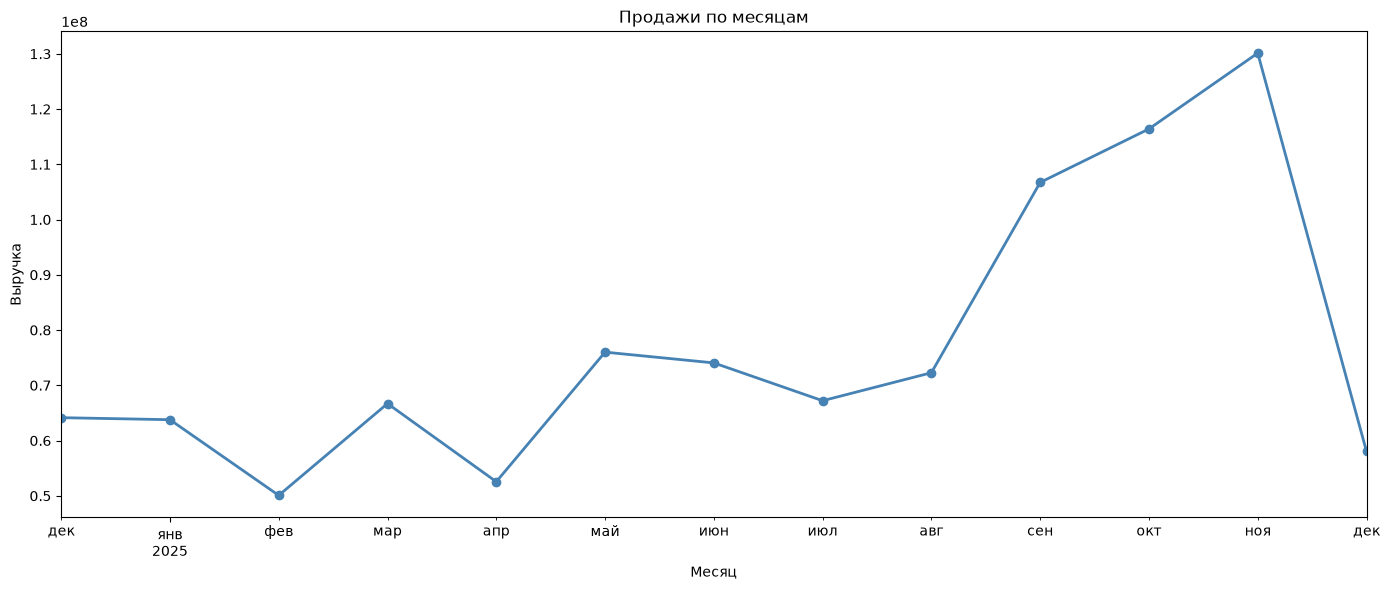

In [58]:
plt.figure(figsize=(14, 6))
monthly.plot(marker='o', color='steelblue', linewidth=2)
plt.title('Продажи по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.tight_layout()
plt.show()

Пик ближе к концу 2025 года, данные за декабрь не полные.